# 17: FD001 less conservative dangerous-error experiment

Este notebook usa solo validacion artificial. El test oficial no se utiliza.

Objetivo: probar alternativas que reduzcan `dangerous_error_pct` sin volverse tan conservadoras como la objective asimetrica dura del notebook 16.

## Plan corto

Se comparan tres ideas:

- objectives alternativas de LightGBM: quantile, huber y asimetricas suaves;
- pesos por RUL moderados cuando aplica;
- offsets chicos sobre el candidato actual para ver si una correccion operacional simple mejora el trade-off.

Criterio practico: bajar dangerous error sin disparar RMSE/C-MAPSS ni sesgar demasiado las predicciones hacia abajo.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / 'CMAPSSData').exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent

import sys
sys.path.append(str(PROJECT_ROOT))

RESULTS_DIR = PROJECT_ROOT / 'results' / 'FD001'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
WINDOW_SIZE = 50
RUL_CAP = 125
DANGEROUS_THRESHOLD = 20


In [2]:
from src.preprocessed_FD001 import prepare_fd001_temporal_validation_only
from src.fd001_experiment_utils import (
    add_operational_error_columns,
    fit_predict_model,
    lgbm_asymmetric_objective_factory,
    lgbm_huber_factory,
    lgbm_quantile_factory,
    metric_row_from_predictions,
    selection_sort,
    shifted_prediction_table,
    weights_from_scheme,
)

prepared = prepare_fd001_temporal_validation_only(
    data_dir=PROJECT_ROOT / 'CMAPSSData',
    eval_size=0.2,
    random_state=RANDOM_STATE,
    max_rul=RUL_CAP,
    cut_ruls=(20, 50, 80, 110, 140),
    window_size=WINDOW_SIZE,
)

prepared = dict(prepared)
prepared['y_train'] = prepared['y_train_raw'].clip(upper=RUL_CAP).copy()

print('train/eval:', prepared['X_train'].shape, prepared['X_eval'].shape)
print('features:', len(prepared['feature_columns']))


train/eval: (16561, 119) (99, 119)
features: 119


## Modelos entrenados en esta prueba

In [3]:
variants = [
    {
        'model_name': 'LGBM_quantile_a045',
        'model': lgbm_quantile_factory(alpha=0.45, random_state=RANDOM_STATE),
        'sample_weight_scheme': 'none',
        'training_objective': 'quantile_alpha_0.45',
    },
    {
        'model_name': 'LGBM_quantile_a040',
        'model': lgbm_quantile_factory(alpha=0.40, random_state=RANDOM_STATE),
        'sample_weight_scheme': 'none',
        'training_objective': 'quantile_alpha_0.40',
    },
    {
        'model_name': 'LGBM_huber_bin_weights',
        'model': lgbm_huber_factory(alpha=0.90, random_state=RANDOM_STATE),
        'sample_weight_scheme': 'bin_weights',
        'training_objective': 'huber_bin_weights',
    },
    {
        'model_name': 'LGBM_asym_soft',
        'model': lgbm_asymmetric_objective_factory(
            random_state=RANDOM_STATE,
            over_scale=18.0,
            under_scale=22.0,
            low_weight=1.4,
            mid_weight=1.2,
            high_weight=1.05,
        ),
        'sample_weight_scheme': 'none',
        'training_objective': 'soft_cmapss_like',
    },
    {
        'model_name': 'LGBM_asym_balanced',
        'model': lgbm_asymmetric_objective_factory(
            random_state=RANDOM_STATE,
            over_scale=16.0,
            under_scale=20.0,
            low_weight=1.8,
            mid_weight=1.35,
            high_weight=1.10,
        ),
        'sample_weight_scheme': 'none',
        'training_objective': 'balanced_cmapss_like',
    },
]

rows = []
prediction_tables = []
bin_tables = []

for variant in variants:
    print('Entrenando', variant['model_name'])
    sample_weight = weights_from_scheme(prepared['y_train_raw'], variant['sample_weight_scheme'])
    pred = fit_predict_model(
        prepared,
        variant['model'],
        variant['model_name'],
        f'temporal_w{WINDOW_SIZE}',
        sample_weight=sample_weight,
    )
    pred['sample_weight_scheme'] = variant['sample_weight_scheme']
    pred['training_objective'] = variant['training_objective']
    row, bins = metric_row_from_predictions(
        pred,
        extra={
            'window_size': WINDOW_SIZE,
            'rul_cap': RUL_CAP,
            'sample_weight_scheme': variant['sample_weight_scheme'],
            'training_objective': variant['training_objective'],
            'experiment_group': 'trained_variant',
        },
    )
    rows.append(row)
    prediction_tables.append(pred)
    bin_tables.append(bins.assign(training_objective=variant['training_objective']))

trained_predictions = pd.concat(prediction_tables, ignore_index=True)
trained_metrics = add_operational_error_columns(pd.DataFrame(rows), trained_predictions)
display(selection_sort(trained_metrics)[[
    'model_name', 'training_objective', 'mae', 'rmse', 'cmapss_score',
    'dangerous_error_pct', 'conservative_error_pct', 'mean_error',
    'mae_rul_0_30', 'mae_rul_60_90', 'mae_rul_90plus'
]])


Entrenando LGBM_quantile_a045


Entrenando LGBM_quantile_a040


Entrenando LGBM_huber_bin_weights


Entrenando LGBM_asym_soft


Entrenando LGBM_asym_balanced


,model_name,training_objective,mae,rmse,cmapss_score,dangerous_error_pct,conservative_error_pct,mean_error,mae_rul_0_30,mae_rul_60_90,mae_rul_90plus
0,LGBM_quantile_a040,quantile_alpha_0.40,11.063333,14.366208,254.947304,4.040404,14.141414,-3.697092,3.720900,14.225841,15.592667
1,LGBM_quantile_a045,quantile_alpha_0.45,11.331264,14.548543,274.957227,7.070707,14.141414,-2.656127,3.837173,14.833474,15.382469
2,LGBM_asym_soft,soft_cmapss_like,11.067665,14.495420,290.026282,10.101010,15.151515,-1.842829,3.260152,15.028417,14.887822
3,LGBM_asym_balanced,balanced_cmapss_like,11.341432,14.623347,305.960773,7.070707,14.141414,-1.739652,3.628083,16.073786,14.965978
4,LGBM_huber_bin_weights,huber_bin_weights,33.775452,40.299197,5637.909285,20.202020,39.393939,-14.867639,37.112157,12.602043,55.276721


## Offsets sobre el candidato actual

In [4]:
base_predictions = pd.read_csv(RESULTS_DIR / 'fd001_lgbm_sample_weight_predictions.csv')
candidate_predictions = base_predictions.loc[
    (base_predictions['model_name'] == 'LGBMRegressor')
    & (base_predictions['representation'] == f'temporal_w{WINDOW_SIZE}')
    & (base_predictions['sample_weight_scheme'] == 'bin_weights')
].copy()

offset_rows = []
offset_tables = []
for offset in [0, 2, 4, 6, 8, 10]:
    name = f'LGBM_bin_weights_offset_{offset}'
    shifted = shifted_prediction_table(candidate_predictions, offset=offset, model_name=name)
    shifted['sample_weight_scheme'] = 'bin_weights'
    shifted['training_objective'] = 'squared_error_post_offset'
    row, _ = metric_row_from_predictions(
        shifted,
        extra={
            'window_size': WINDOW_SIZE,
            'rul_cap': RUL_CAP,
            'sample_weight_scheme': 'bin_weights',
            'training_objective': 'squared_error_post_offset',
            'prediction_offset': offset,
            'experiment_group': 'post_offset',
        },
    )
    offset_rows.append(row)
    offset_tables.append(shifted)

offset_predictions = pd.concat(offset_tables, ignore_index=True)
offset_metrics = add_operational_error_columns(pd.DataFrame(offset_rows), offset_predictions)
display(offset_metrics[[
    'model_name', 'prediction_offset', 'mae', 'rmse', 'cmapss_score',
    'dangerous_error_pct', 'conservative_error_pct', 'mean_error', 'mae_rul_0_30', 'mae_rul_90plus'
]])


,model_name,prediction_offset,mae,rmse,cmapss_score,dangerous_error_pct,conservative_error_pct,mean_error,mae_rul_0_30,mae_rul_90plus
0,LGBM_bin_weights_offset_0,0,11.194267,14.037945,251.554310,7.070707,13.131313,-2.019054,3.788301,15.341870
1,LGBM_bin_weights_offset_2,2,11.307966,14.461678,250.306114,6.060606,15.151515,-4.019054,3.451115,16.213665
2,LGBM_bin_weights_offset_4,4,11.675252,15.139893,261.828337,5.050505,19.191919,-6.019054,4.013164,17.168632
3,LGBM_bin_weights_offset_6,6,12.365387,16.040342,286.480558,1.010101,22.222222,-8.019054,5.347285,18.393590
4,LGBM_bin_weights_offset_8,8,13.354857,17.128012,324.212595,0.000000,24.242424,-10.019054,6.843329,19.920114
5,LGBM_bin_weights_offset_10,10,14.650581,18.369676,375.627918,0.000000,29.292929,-12.019054,8.612986,21.596138


## Comparacion final de la prueba

In [5]:
previous = pd.read_csv(RESULTS_DIR / 'fd001_lgbm_asymmetric_objective_metrics.csv')
previous = previous.loc[
    previous['model_name'] == 'LGBMRegressor_cmapss_weighted_objective'
].copy()

sample_weight_metrics = pd.read_csv(RESULTS_DIR / 'fd001_lgbm_sample_weight_search.csv')
current_reference = sample_weight_metrics.loc[
    sample_weight_metrics['sample_weight_scheme'].isin(['none', 'bin_weights'])
].copy()
current_reference['training_objective'] = 'squared_error'
current_reference['experiment_group'] = 'current_reference'
current_reference['prediction_offset'] = 0

current_predictions = base_predictions.loc[
    (base_predictions['model_name'] == 'LGBMRegressor')
    & (base_predictions['representation'] == f'temporal_w{WINDOW_SIZE}')
    & (base_predictions['sample_weight_scheme'].isin(['none', 'bin_weights']))
].copy()
current_predictions['training_objective'] = 'squared_error'
current_reference = add_operational_error_columns(current_reference, current_predictions)

comparison = pd.concat([
    current_reference,
    previous,
    trained_metrics,
    offset_metrics,
], ignore_index=True, sort=False)

comparison = selection_sort(comparison)
comparison.to_csv(RESULTS_DIR / 'fd001_less_conservative_dangerous_error_metrics.csv', index=False)
pd.concat([trained_predictions, offset_predictions], ignore_index=True).to_csv(
    RESULTS_DIR / 'fd001_less_conservative_dangerous_error_predictions.csv', index=False
)
if bin_tables:
    pd.concat(bin_tables, ignore_index=True).to_csv(
        RESULTS_DIR / 'fd001_less_conservative_dangerous_error_metrics_by_rul_bin.csv', index=False
    )

cols = [
    'model_name', 'experiment_group', 'training_objective', 'sample_weight_scheme',
    'prediction_offset', 'mae', 'rmse', 'cmapss_score', 'dangerous_error_pct',
    'conservative_error_pct', 'mean_error', 'mae_rul_0_30', 'mae_rul_60_90', 'mae_rul_90plus'
]
display(comparison[[c for c in cols if c in comparison.columns]].head(14))


,model_name,experiment_group,training_objective,sample_weight_scheme,prediction_offset,mae,rmse,cmapss_score,dangerous_error_pct,conservative_error_pct,mean_error,mae_rul_0_30,mae_rul_60_90,mae_rul_90plus
0,LGBM_bin_weights_offset_2,post_offset,squared_error_post_offset,bin_weights,2.0,11.307966,14.461678,250.306114,6.060606,15.151515,-4.019054,3.451115,13.825283,16.213665
1,LGBMRegressor,current_reference,squared_error,bin_weights,0.0,11.194267,14.037945,251.554310,7.070707,13.131313,-2.019054,3.788301,14.225283,15.341870
2,LGBM_bin_weights_offset_0,post_offset,squared_error_post_offset,bin_weights,0.0,11.194267,14.037945,251.554310,7.070707,13.131313,-2.019054,3.788301,14.225283,15.341870
3,LGBM_quantile_a040,trained_variant,quantile_alpha_0.40,none,NaN,11.063333,14.366208,254.947304,4.040404,14.141414,-3.697092,3.720900,14.225841,15.592667
4,LGBMRegressor,current_reference,squared_error,none,0.0,11.297658,14.428233,261.005416,6.060606,14.141414,-2.321288,4.269154,14.934006,15.475423
5,LGBM_bin_weights_offset_4,post_offset,squared_error_post_offset,bin_weights,4.0,11.675252,15.139893,261.828337,5.050505,19.191919,-6.019054,4.013164,13.425283,17.168632
6,LGBM_quantile_a045,trained_variant,quantile_alpha_0.45,none,NaN,11.331264,14.548543,274.957227,7.070707,14.141414,-2.656127,3.837173,14.833474,15.382469
7,LGBM_bin_weights_offset_6,post_offset,squared_error_post_offset,bin_weights,6.0,12.365387,16.040342,286.480558,1.010101,22.222222,-8.019054,5.347285,13.025283,18.393590
8,LGBM_asym_soft,trained_variant,soft_cmapss_like,none,NaN,11.067665,14.495420,290.026282,10.101010,15.151515,-1.842829,3.260152,15.028417,14.887822
9,LGBM_asym_balanced,trained_variant,balanced_cmapss_like,none,NaN,11.341432,14.623347,305.960773,7.070707,14.141414,-1.739652,3.628083,16.073786,14.965978


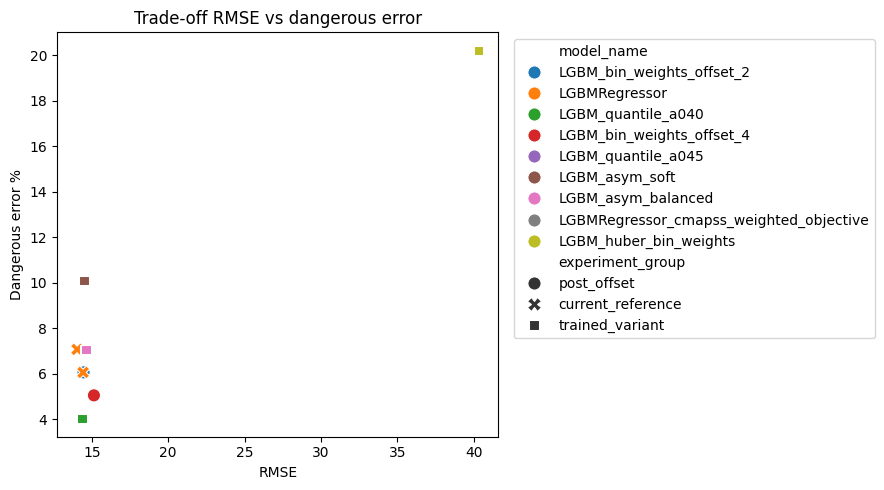

In [6]:
plot_df = comparison.loc[
    comparison['model_name'].isin([
        'LGBMRegressor',
        'LGBM_bin_weights_offset_2',
        'LGBM_bin_weights_offset_4',
        'LGBM_quantile_a045',
        'LGBM_quantile_a040',
        'LGBM_huber_bin_weights',
        'LGBM_asym_soft',
        'LGBM_asym_balanced',
        'LGBMRegressor_cmapss_weighted_objective',
    ])
].copy()

plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=plot_df,
    x='rmse',
    y='dangerous_error_pct',
    hue='model_name',
    style='experiment_group',
    s=90,
)
plt.title('Trade-off RMSE vs dangerous error')
plt.xlabel('RMSE')
plt.ylabel('Dangerous error %')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


## Lectura corta

- La mejor alternativa entrenada fue `LGBM_quantile_a040`: baja dangerous error de 7.07% a 4.04%, con RMSE 14.37 y C-MAPSS 254.95. Es un trade-off razonable: casi mantiene el rendimiento global y reduce bastante las sobreestimaciones peligrosas.
- El offset de 2 ciclos sobre el candidato actual tambien es competitivo: dangerous error baja a 6.06% y C-MAPSS queda en 250.31, apenas mejor que el candidato, pero con un sesgo mas conservador.
- El offset de 6 u 8 ciclos baja mucho o elimina dangerous error, pero ya empieza a pagar demasiado en RMSE y subestimacion.
- Las objectives asimetricas suaves no superaron a `quantile_a040`; la objective dura del notebook 16 sigue descartada porque rompe el error global.

Conclusion: vale la pena seguir mirando `LGBM_quantile_a040` como candidato alternativo menos riesgoso. No reemplaza automaticamente al candidato principal, pero es la primera prueba que baja dangerous error sin volverse exageradamente conservadora.